# Predicción de Calidad de Concentrado de Hierro

### Problematica: 
La sílice en el concentrado de hierro es principalmente una impureza indeseada que aumenta costos y energía, aumentando la escoria o dificultando la aglomeración, debiendo ser controlada y eliminada mediante procesos de flotación o separación magnética antes de entrar al horno, para asegurar un proceso eficiente y un producto final de alta calidad. 
### Objetivo: 
Predecir el % de impurezas (% silice) presente en el producto final (concentrado de hierro) durante el proceso de flotación, con datos proveniente de sensores de una planta metalúrgica.
### Metodología: 
Se explorara el dataset mediante algoritmos de Machine Learning y de Deep Learning para obtener información relevante de los datos y realizar predicciones.
### Propuesta de valor:
predecir la calidad de hierro permite aumentar el ritmo de producción y eficiencia.

### Observaciones:
* Para el siguiente proyecto no se consideró incluir los datos temporales que incluye el dataset, simplemente para centrarse en la comparación de diferentes implementaciones de modelos de Machine Learning y Deep Learning.
* En otra oportunidad se abordará este problema mediante técnicas optimas para series temporales, como LSTM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

## Carga de Dataset y Estadisticas

In [2]:
mining_df = pd.read_csv('data/mining_data.csv')

In [3]:
mining_df

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,55.20,16.98,3196.680000,542.694333,396.284000,10.158367,1.668070,249.796333,250.275667,248.668000,...,250.547000,464.978667,490.450333,443.465000,442.856333,438.782333,452.248333,466.300667,67.06,1.11
1,55.20,16.98,3213.673333,540.649333,397.949333,10.156600,1.664973,249.536000,250.752000,250.968333,...,249.807000,445.001000,362.894667,442.748333,471.045333,445.239667,443.630667,426.921667,67.06,1.11
2,55.20,16.98,3180.080000,535.929333,397.305000,10.154800,1.661877,249.576000,250.279667,251.001333,...,249.686667,443.574667,478.916333,432.779333,437.401667,441.761000,490.824667,478.046667,67.06,1.11
3,55.20,16.98,3196.713333,535.102000,397.010667,10.153067,1.658780,249.380333,248.799333,250.241333,...,249.926333,440.731333,488.994000,452.461333,439.572667,434.027333,457.083667,458.815667,67.06,1.11
4,55.20,16.98,3111.723333,532.735000,395.263667,10.151300,1.655680,249.426667,252.209667,249.243333,...,249.975667,445.851667,418.860000,462.936667,454.948333,453.571667,446.831667,426.600000,67.06,1.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245695,49.75,23.20,2961.490000,452.658667,381.784667,9.615990,1.654507,300.351000,295.703667,298.312667,...,321.464444,404.055667,523.933667,880.286833,331.448333,500.245000,424.037667,400.798000,64.27,1.71
245696,49.75,23.20,2851.376667,470.843333,384.250000,9.617760,1.654413,299.978667,304.478333,301.176667,...,335.351222,417.104667,548.184333,883.347000,388.821000,482.577333,338.373000,371.803333,64.27,1.71
245697,49.75,23.20,2729.876667,463.040667,383.073667,9.619523,1.654070,302.416667,299.060000,299.929000,...,291.529000,386.853000,546.765000,870.141667,435.600333,488.983667,420.578667,366.426333,64.27,1.71
245698,49.75,23.20,2698.756667,460.303667,384.490667,9.620873,1.653653,302.603000,299.953333,299.483667,...,285.945000,395.502667,443.776333,872.247333,416.832667,495.943333,437.163000,417.842667,64.27,1.71


In [4]:
mining_df.dtypes

% Iron Feed                     float64
% Silica Feed                   float64
Starch Flow                     float64
Amina Flow                      float64
Ore Pulp Flow                   float64
Ore Pulp pH                     float64
Ore Pulp Density                float64
Flotation Column 01 Air Flow    float64
Flotation Column 02 Air Flow    float64
Flotation Column 03 Air Flow    float64
Flotation Column 04 Air Flow    float64
Flotation Column 05 Air Flow    float64
Flotation Column 06 Air Flow    float64
Flotation Column 07 Air Flow    float64
Flotation Column 01 Level       float64
Flotation Column 02 Level       float64
Flotation Column 03 Level       float64
Flotation Column 04 Level       float64
Flotation Column 05 Level       float64
Flotation Column 06 Level       float64
Flotation Column 07 Level       float64
% Iron Concentrate              float64
% Silica Concentrate            float64
dtype: object

In [5]:
# analizamos si existen valores nulos

mining_df.isnull()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245695,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
245696,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
245697,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
245698,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [6]:
mining_df.isnull().sum()

% Iron Feed                     0
% Silica Feed                   0
Starch Flow                     0
Amina Flow                      0
Ore Pulp Flow                   0
Ore Pulp pH                     0
Ore Pulp Density                0
Flotation Column 01 Air Flow    0
Flotation Column 02 Air Flow    0
Flotation Column 03 Air Flow    0
Flotation Column 04 Air Flow    0
Flotation Column 05 Air Flow    0
Flotation Column 06 Air Flow    0
Flotation Column 07 Air Flow    0
Flotation Column 01 Level       0
Flotation Column 02 Level       0
Flotation Column 03 Level       0
Flotation Column 04 Level       0
Flotation Column 05 Level       0
Flotation Column 06 Level       0
Flotation Column 07 Level       0
% Iron Concentrate              0
% Silica Concentrate            0
dtype: int64

In [7]:
mining_df.describe() # Estadisticas descriptivas

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,...,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000,245700.000000
mean,56.294974,14.651438,2869.241181,488.144186,397.577332,9.767534,1.680348,280.166032,277.172893,281.097236,...,290.774336,520.242050,522.648563,531.355055,420.306805,425.237994,429.927646,421.006767,65.049435,2.327228
std,5.158958,6.808961,1187.990184,90.736360,9.468496,0.387036,0.069213,29.616570,29.936823,28.537193,...,28.158596,130.389539,127.450562,150.614529,90.566437,83.601851,85.320602,83.736727,1.118479,1.125623
min,42.740000,1.310000,0.074147,241.699632,376.272600,8.753370,1.519829,175.666333,175.923177,176.471917,...,186.074077,149.451600,211.266111,126.352031,162.293185,167.139620,161.485667,175.908240,62.050000,0.600000
25%,52.670000,8.940000,2073.322500,432.204667,395.212583,9.527158,1.647197,250.268667,250.367333,250.693667,...,263.524333,413.516320,442.291000,410.134583,356.440167,357.074583,358.078583,356.567833,64.370000,1.440000
50%,56.080000,13.850000,2994.311667,504.510667,399.354833,9.797963,1.697560,299.418000,297.433000,299.048333,...,299.350833,492.971167,496.380667,494.859500,410.511667,408.022833,419.931167,410.043333,65.210000,2.000000
75%,59.720000,19.600000,3712.951667,553.479083,402.458750,10.037833,1.728257,300.127333,300.435000,300.308667,...,301.239667,594.960083,595.989167,601.060000,486.533417,485.580833,490.725500,475.922283,65.860000,3.010000
max,65.780000,33.400000,6295.130657,739.422405,418.625439,10.808046,1.853229,372.387588,369.550000,359.948635,...,370.190800,862.197932,828.593000,886.820204,680.019967,675.571459,698.621871,659.618696,68.010000,5.530000


## Análisis Exploratorio de Datos

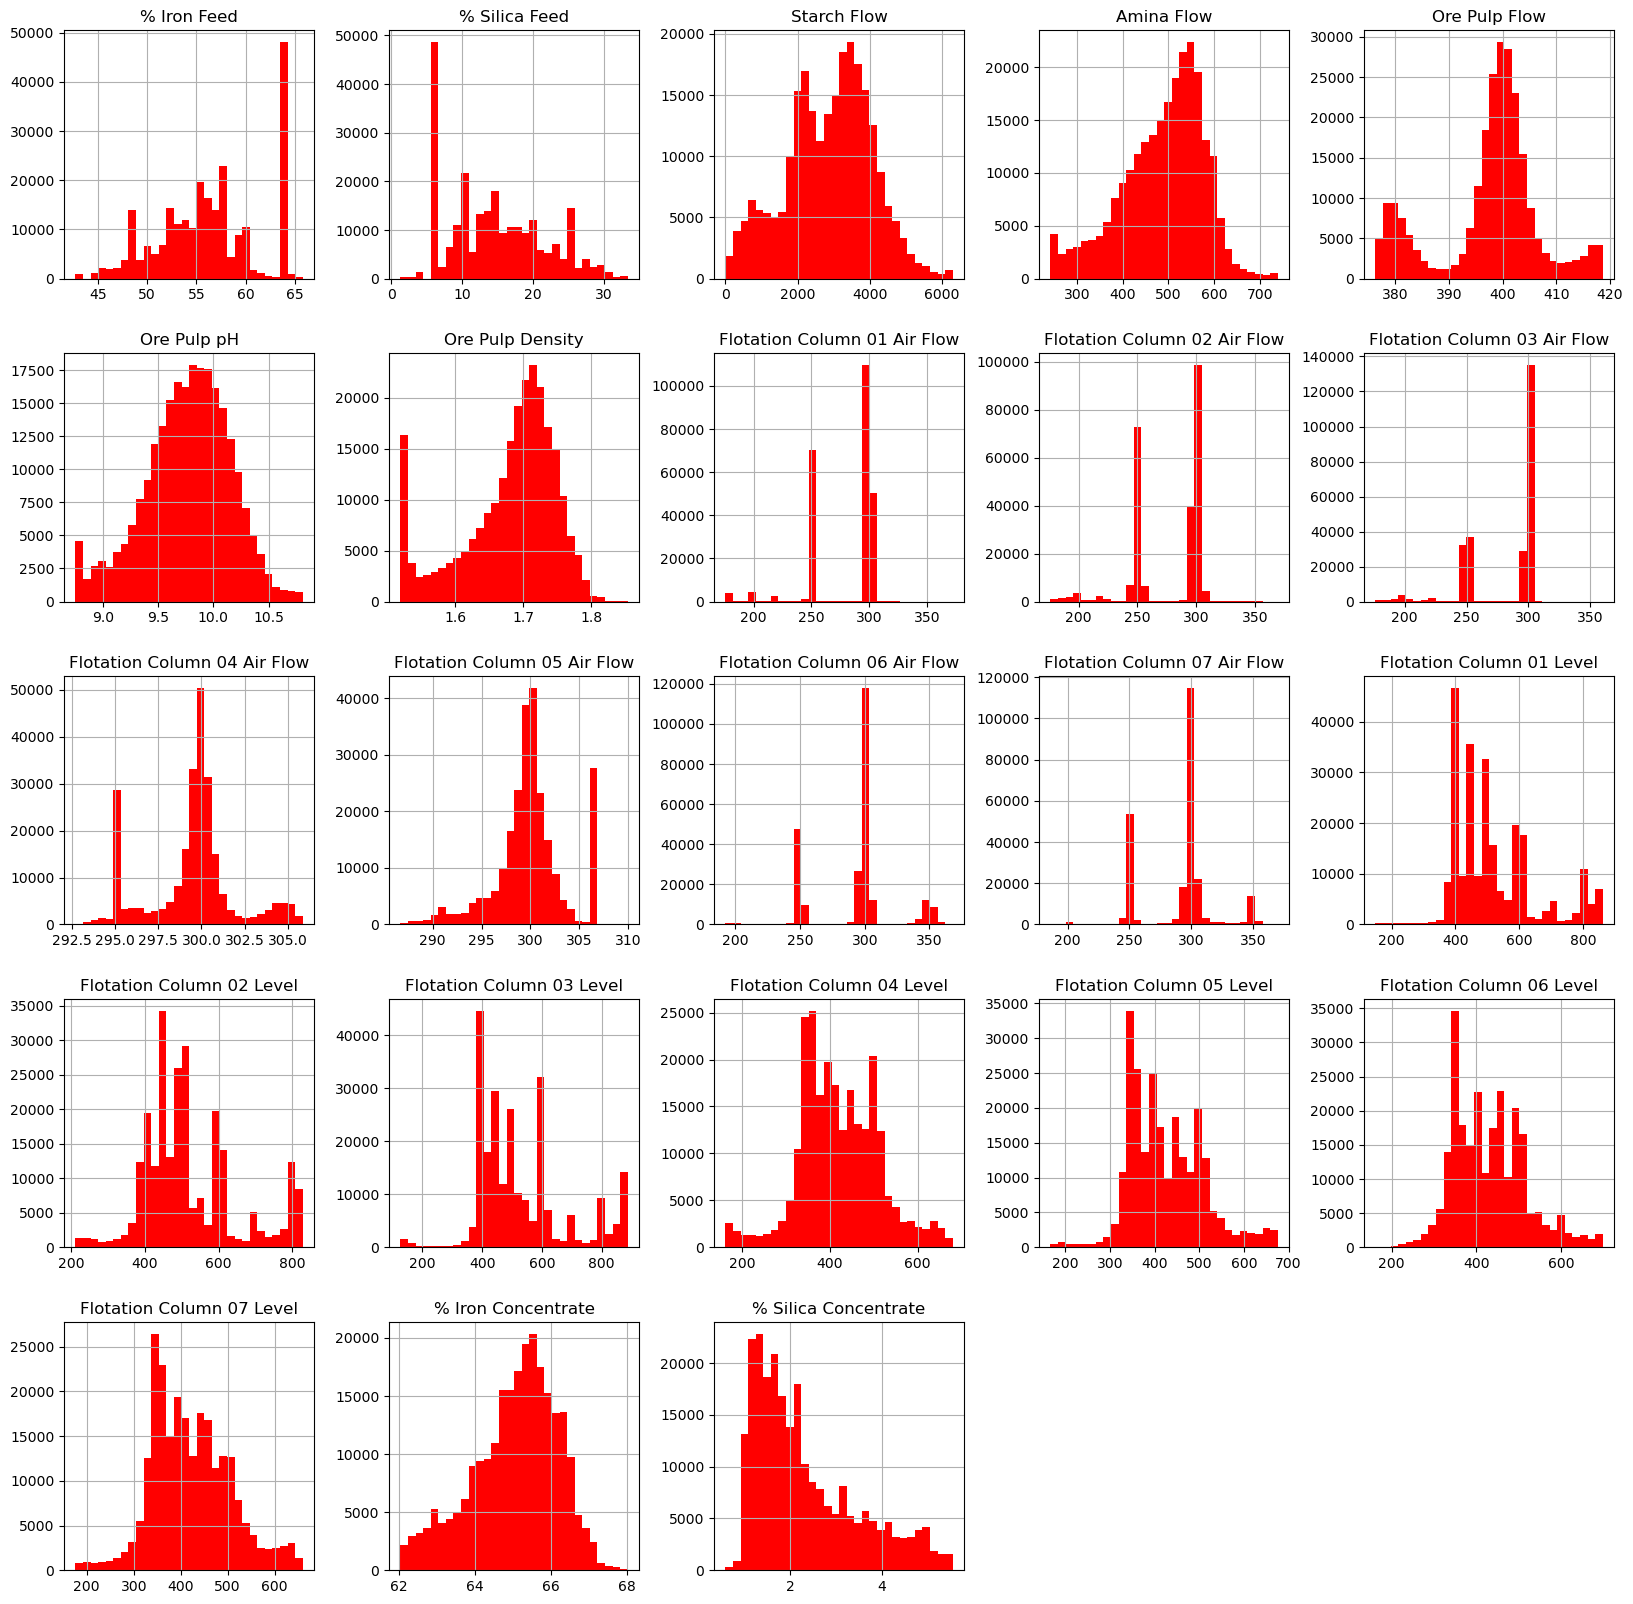

In [8]:
mining_df.hist(bins = 30, figsize = (20,20), color ='r')
plt.show()

### Matriz de correlación

In [9]:
mining_df.corr()

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
% Iron Feed,1.000000,-0.971837,0.028644,-0.088595,0.164676,0.007496,-0.125583,-0.062448,-0.170716,-0.062318,...,-0.016722,0.029619,0.020928,0.015189,0.016346,0.023571,0.003910,0.026100,0.055526,-0.077108
% Silica Feed,-0.971837,1.000000,-0.016489,0.079065,-0.154508,0.007953,0.104567,0.091833,0.183953,0.084325,...,0.046193,-0.038417,-0.037113,-0.022653,-0.034534,-0.044270,-0.020568,-0.047079,-0.044292,0.072778
Starch Flow,0.028644,-0.016489,1.000000,0.261934,0.044926,0.269135,0.231530,0.195538,0.192244,0.187602,...,0.202817,-0.302567,-0.286336,-0.309177,-0.013037,-0.057417,-0.077105,-0.039584,0.071303,-0.068008
Amina Flow,-0.088595,0.079065,0.261934,1.000000,0.219162,0.124254,0.659461,0.111994,0.124490,0.102632,...,0.081561,-0.270753,-0.236452,-0.288484,-0.183739,-0.215334,-0.209496,-0.171384,-0.111045,0.157644
Ore Pulp Flow,0.164676,-0.154508,0.044926,0.219162,1.000000,0.121256,0.012571,-0.141215,-0.122322,-0.144232,...,-0.146904,-0.008877,-0.008335,-0.055890,-0.010212,0.002158,-0.018051,0.017185,0.085098,0.008519
Ore Pulp pH,0.007496,0.007953,0.269135,0.124254,0.121256,1.000000,0.115073,0.163433,0.146264,0.193887,...,0.178322,-0.166525,-0.154391,-0.140251,0.046933,0.013095,-0.079157,0.019193,0.192705,-0.147550
Ore Pulp Density,-0.125583,0.104567,0.231530,0.659461,0.012571,0.115073,1.000000,-0.004695,0.026413,-0.031237,...,-0.052655,-0.112201,-0.093542,-0.149823,-0.089066,-0.142675,-0.105346,-0.087454,0.015116,0.047413
Flotation Column 01 Air Flow,-0.062448,0.091833,0.195538,0.111994,-0.141215,0.163433,-0.004695,1.000000,0.854298,0.955256,...,0.658199,-0.443870,-0.428294,-0.372533,-0.062665,-0.092254,-0.125196,-0.112074,0.099239,-0.219698
Flotation Column 02 Air Flow,-0.170716,0.183953,0.192244,0.124490,-0.122322,0.146264,0.026413,0.854298,1.000000,0.866927,...,0.592888,-0.437313,-0.428303,-0.368913,-0.075833,-0.112465,-0.124478,-0.114693,0.059709,-0.169029
Flotation Column 03 Air Flow,-0.062318,0.084325,0.187602,0.102632,-0.144232,0.193887,-0.031237,0.955256,0.866927,1.000000,...,0.661261,-0.443454,-0.423836,-0.365800,-0.047216,-0.064355,-0.105673,-0.086448,0.100888,-0.219593


<Axes: >

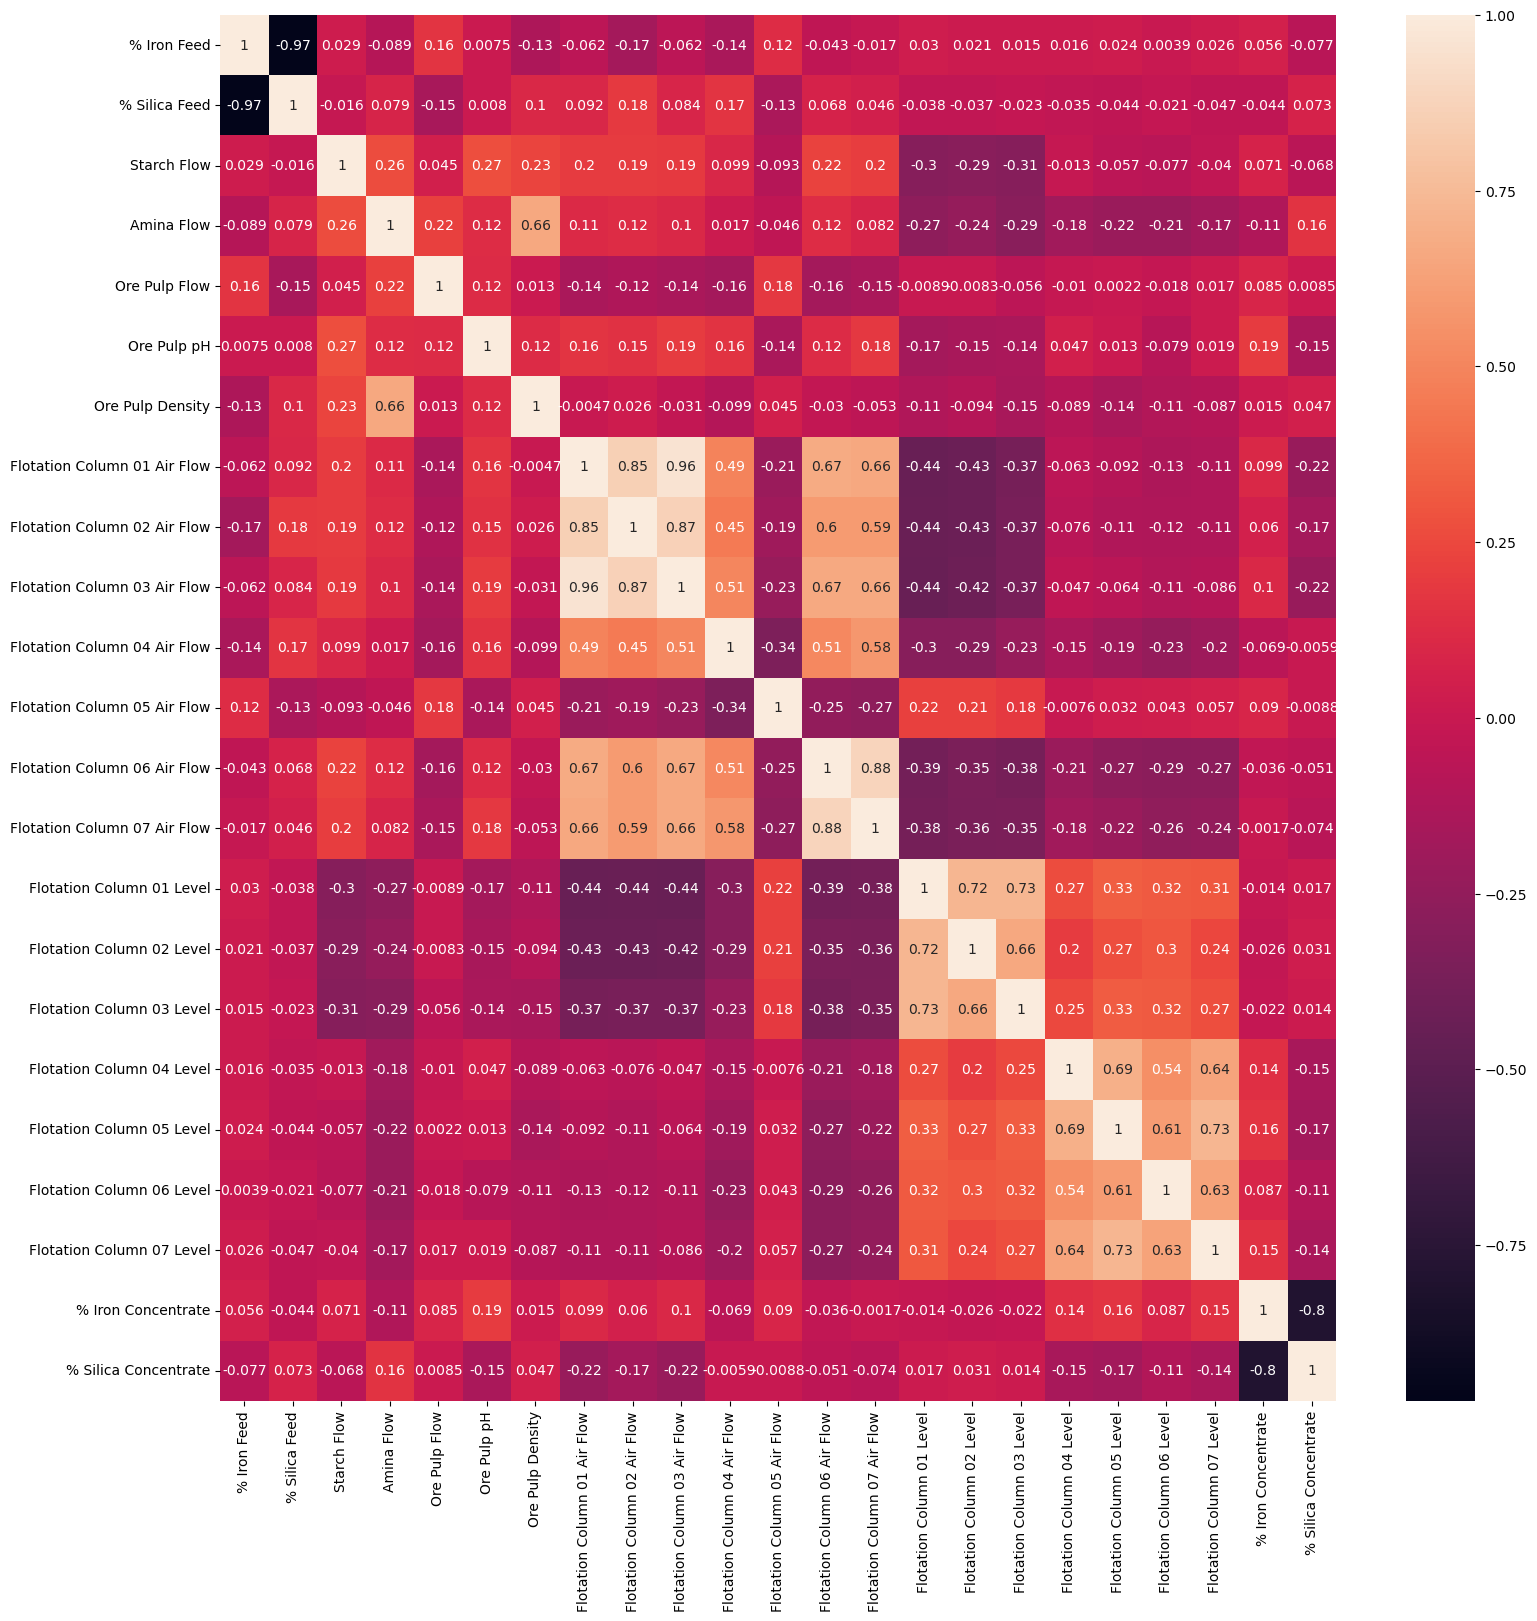

In [10]:
plt.figure(figsize = (18,18))
sns.heatmap(mining_df.corr(), annot= True)

### Gráficos de dispersión
* estos gráficos son simples ejemplos de visualización

#### % concentrado Si vs % concentrado Fe

<Axes: xlabel='% Silica Concentrate', ylabel='% Iron Concentrate'>

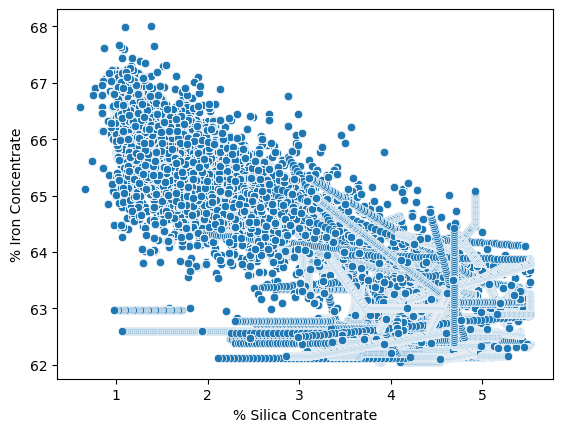

In [11]:
sns.scatterplot(x= mining_df['% Silica Concentrate'], y= mining_df['% Iron Concentrate'])

* **Este gráfico nos muestra un error importante si pretendemos predecir el % de silice en el concentrado**: % Iron Concentrate y % Silica Concentrate ambas son variables de salida del proceso de flotación, osea, se miden simulataáneamente en el producto final.
* Incluir % Iron Concentrate como feature de entrada equivale a predecir y usando y, porque ambas están determinadas en el mismo proceso físico.
* Incluirlo implica un Data Leakeage

#### % Alimentación Si vs % Alimentación Fe

<Axes: xlabel='% Iron Feed', ylabel='% Silica Feed'>

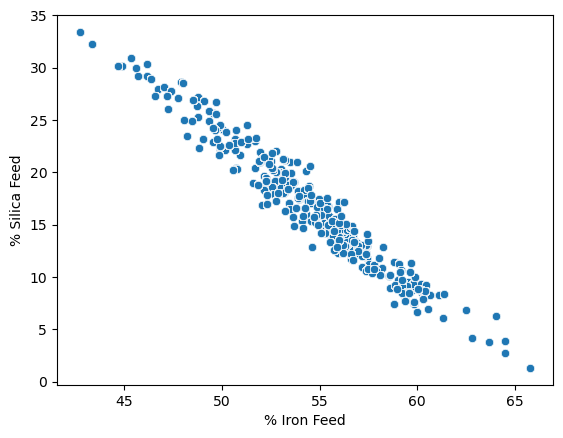

In [12]:
sns.scatterplot(x=mining_df['% Iron Feed'],y=mining_df['% Silica Feed'])

* el grafico nos muestra una correlación negativa entre ambas variables.

## Preprocesamiento de Datos
* la variable a predecir es '% Silica Concentrate' (output)
* los imputs del modelo de ML serán todos los features restantes.

In [13]:
mining_df

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,55.20,16.98,3196.680000,542.694333,396.284000,10.158367,1.668070,249.796333,250.275667,248.668000,...,250.547000,464.978667,490.450333,443.465000,442.856333,438.782333,452.248333,466.300667,67.06,1.11
1,55.20,16.98,3213.673333,540.649333,397.949333,10.156600,1.664973,249.536000,250.752000,250.968333,...,249.807000,445.001000,362.894667,442.748333,471.045333,445.239667,443.630667,426.921667,67.06,1.11
2,55.20,16.98,3180.080000,535.929333,397.305000,10.154800,1.661877,249.576000,250.279667,251.001333,...,249.686667,443.574667,478.916333,432.779333,437.401667,441.761000,490.824667,478.046667,67.06,1.11
3,55.20,16.98,3196.713333,535.102000,397.010667,10.153067,1.658780,249.380333,248.799333,250.241333,...,249.926333,440.731333,488.994000,452.461333,439.572667,434.027333,457.083667,458.815667,67.06,1.11
4,55.20,16.98,3111.723333,532.735000,395.263667,10.151300,1.655680,249.426667,252.209667,249.243333,...,249.975667,445.851667,418.860000,462.936667,454.948333,453.571667,446.831667,426.600000,67.06,1.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245695,49.75,23.20,2961.490000,452.658667,381.784667,9.615990,1.654507,300.351000,295.703667,298.312667,...,321.464444,404.055667,523.933667,880.286833,331.448333,500.245000,424.037667,400.798000,64.27,1.71
245696,49.75,23.20,2851.376667,470.843333,384.250000,9.617760,1.654413,299.978667,304.478333,301.176667,...,335.351222,417.104667,548.184333,883.347000,388.821000,482.577333,338.373000,371.803333,64.27,1.71
245697,49.75,23.20,2729.876667,463.040667,383.073667,9.619523,1.654070,302.416667,299.060000,299.929000,...,291.529000,386.853000,546.765000,870.141667,435.600333,488.983667,420.578667,366.426333,64.27,1.71
245698,49.75,23.20,2698.756667,460.303667,384.490667,9.620873,1.653653,302.603000,299.953333,299.483667,...,285.945000,395.502667,443.776333,872.247333,416.832667,495.943333,437.163000,417.842667,64.27,1.71


In [14]:
mining_df.value_counts

<bound method DataFrame.value_counts of         % Iron Feed  % Silica Feed  Starch Flow  Amina Flow  Ore Pulp Flow  \
0             55.20          16.98  3196.680000  542.694333     396.284000   
1             55.20          16.98  3213.673333  540.649333     397.949333   
2             55.20          16.98  3180.080000  535.929333     397.305000   
3             55.20          16.98  3196.713333  535.102000     397.010667   
4             55.20          16.98  3111.723333  532.735000     395.263667   
...             ...            ...          ...         ...            ...   
245695        49.75          23.20  2961.490000  452.658667     381.784667   
245696        49.75          23.20  2851.376667  470.843333     384.250000   
245697        49.75          23.20  2729.876667  463.040667     383.073667   
245698        49.75          23.20  2698.756667  460.303667     384.490667   
245699        49.75          23.20  1673.480000  486.685000     384.424333   

        Ore Pulp pH  Or

In [15]:
# Separamos X e y
X = mining_df.drop(columns=['% Iron Concentrate','% Silica Concentrate']) # X (inputs)
y = mining_df['% Silica Concentrate'] # y (predicción)

In [16]:
X.shape

(245700, 21)

In [17]:
X.head(10)

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level
0,55.2,16.98,3196.680000,542.694333,396.284000,10.158367,1.668070,249.796333,250.275667,248.668000,...,306.4,250.447667,250.547000,464.978667,490.450333,443.465000,442.856333,438.782333,452.248333,466.300667
1,55.2,16.98,3213.673333,540.649333,397.949333,10.156600,1.664973,249.536000,250.752000,250.968333,...,306.4,250.235667,249.807000,445.001000,362.894667,442.748333,471.045333,445.239667,443.630667,426.921667
2,55.2,16.98,3180.080000,535.929333,397.305000,10.154800,1.661877,249.576000,250.279667,251.001333,...,306.4,250.634667,249.686667,443.574667,478.916333,432.779333,437.401667,441.761000,490.824667,478.046667
3,55.2,16.98,3196.713333,535.102000,397.010667,10.153067,1.658780,249.380333,248.799333,250.241333,...,306.4,249.928000,249.926333,440.731333,488.994000,452.461333,439.572667,434.027333,457.083667,458.815667
4,55.2,16.98,3111.723333,532.735000,395.263667,10.151300,1.655680,249.426667,252.209667,249.243333,...,306.4,250.195667,249.975667,445.851667,418.860000,462.936667,454.948333,453.571667,446.831667,426.600000
5,55.2,16.98,2864.550000,527.852333,395.557000,10.149500,1.652580,249.170000,249.389667,248.877000,...,306.4,250.085667,248.693667,473.128333,435.095000,464.376667,445.246667,462.105000,470.356667,476.535000
6,55.2,16.98,2809.896667,517.680000,399.512000,10.147800,1.649483,249.609333,250.671000,251.037333,...,306.4,249.829000,249.463000,447.770333,452.465000,445.940000,447.463333,451.363333,440.303333,462.095000
7,55.2,16.98,2846.026667,520.629667,401.025333,10.146000,1.646377,249.426333,251.367333,251.184000,...,306.4,249.975667,250.012333,439.012000,506.085000,435.418333,443.685000,435.483333,458.783333,429.913333
8,55.2,16.98,2877.930000,520.426333,403.906000,10.145933,1.643277,249.499667,250.964333,248.510667,...,306.4,250.232000,250.415000,454.193333,416.778333,443.690000,462.758333,460.453333,443.940000,448.026667
9,55.2,16.98,3025.393333,517.578000,403.711333,10.151500,1.640173,249.353000,248.437333,250.891000,...,306.4,250.122333,249.829000,446.102000,421.500000,449.536667,450.975000,468.623333,463.356667,488.950000


In [18]:
y.shape

(245700,)

In [19]:
y.head(10)

0    1.11
1    1.11
2    1.11
3    1.11
4    1.11
5    1.11
6    1.11
7    1.11
8    1.11
9    1.11
Name: % Silica Concentrate, dtype: float64

In [20]:
# Conversión de df a arrays de numpy

X = np.array(X)
y = np.array(y)

In [21]:
# Reshaping el array (esencial para entrenar el modelo de ML )

#y = df_iron_target.reshape(-1,1) # batch format
#y.shape

### Separación de trainset y testset

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False) # 80% del dataset será para entrenamiento

In [24]:
X_train.shape

(196560, 21)

In [25]:
X_test.shape

(49140, 21)

In [26]:
y_train.shape

(196560,)

In [27]:
y_test.shape

(49140,)

### Escalamiento de datos
* Escencial antes de entrenar modelos de ML o de DL
* Escalar los datos evita que, por ejemplo, una red neuronal se confunda y no aprenda bien.

In [28]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test  = scaler_x.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test  = scaler_y.transform(y_test.reshape(-1, 1))

In [29]:
X.shape

(245700, 21)

In [30]:
y.shape

(245700,)

## Entrenamiento de un modelo de regresión lineal

### Regresión Lineal:
* una regresión lineal simple consiste en predecir el valor de una variable y basado en una variable X.
* **X** es llamada la **variable independiente**, mientras **y** es la variable **dependiente**.
* por qué simple?: porque examina la relación entre solo dos variables.
* por qué lineal?: porque si la variable independiente crece o decrece, la variable dependiente crece o decrece con un comportamiento lineal.
* En este modelo tendremos multiples variables independientes, por lo que se trabajará con una **Regresión Lineal Multiple**.

 Regresión Lineal Múltiple: $$y =b_{0} + \sum_{i=1}^{n}b_{i}*x_{i}$$

<div>
<center>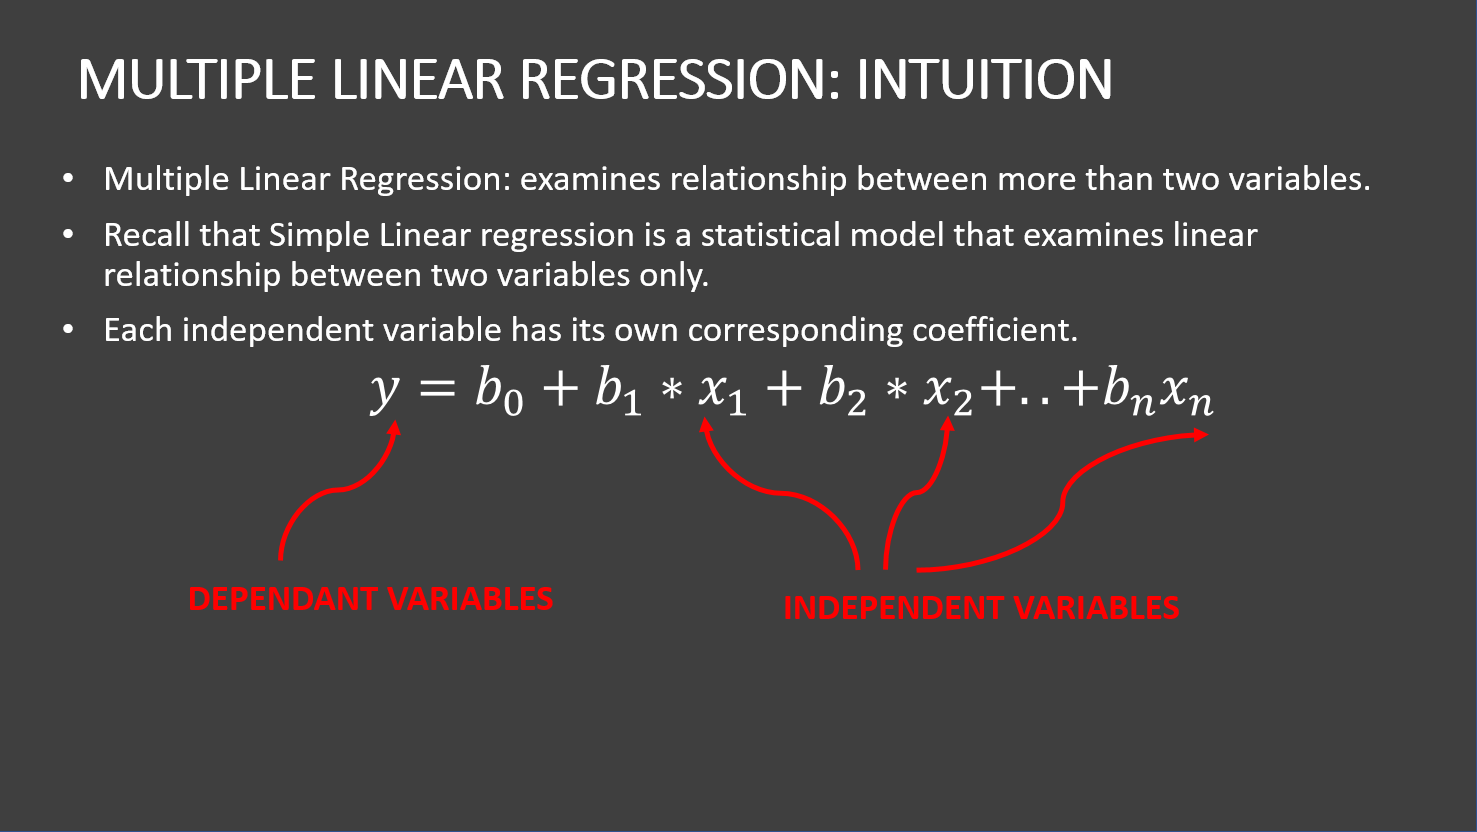<center>
</div>

* Primero debemos encontar una forma de calcular el valor de los coeficientes o párametros (b), pensando en encontrar la línea recta que mejor se ajuste al conjunto de datos.
* Para esto en tareas de regresión se utiliza comunmente el **Método de Mínimos Cuadrados**, que es una técnica de **optimización matemática**.
* Encontrar la mejor línea recta que se ajusta a los datos implica **minimizar la suma de los residuales cuadrados** (osea, las diferencias entre los valores observados ( $y$ ) y los valores predecidos o estimados ( $\hat{y}$ ), a esto también se le llama **minimizar el error cuadratico**.

Optimización por Mínimos Cuadrados: 
$$ d (residuales) =  y_{i} - \hat{y}_{i}$$
$$ b = Min\sum_{i=1}^{n}( y_{i} - \hat{y}_{i} )$$ 
<div>
<center>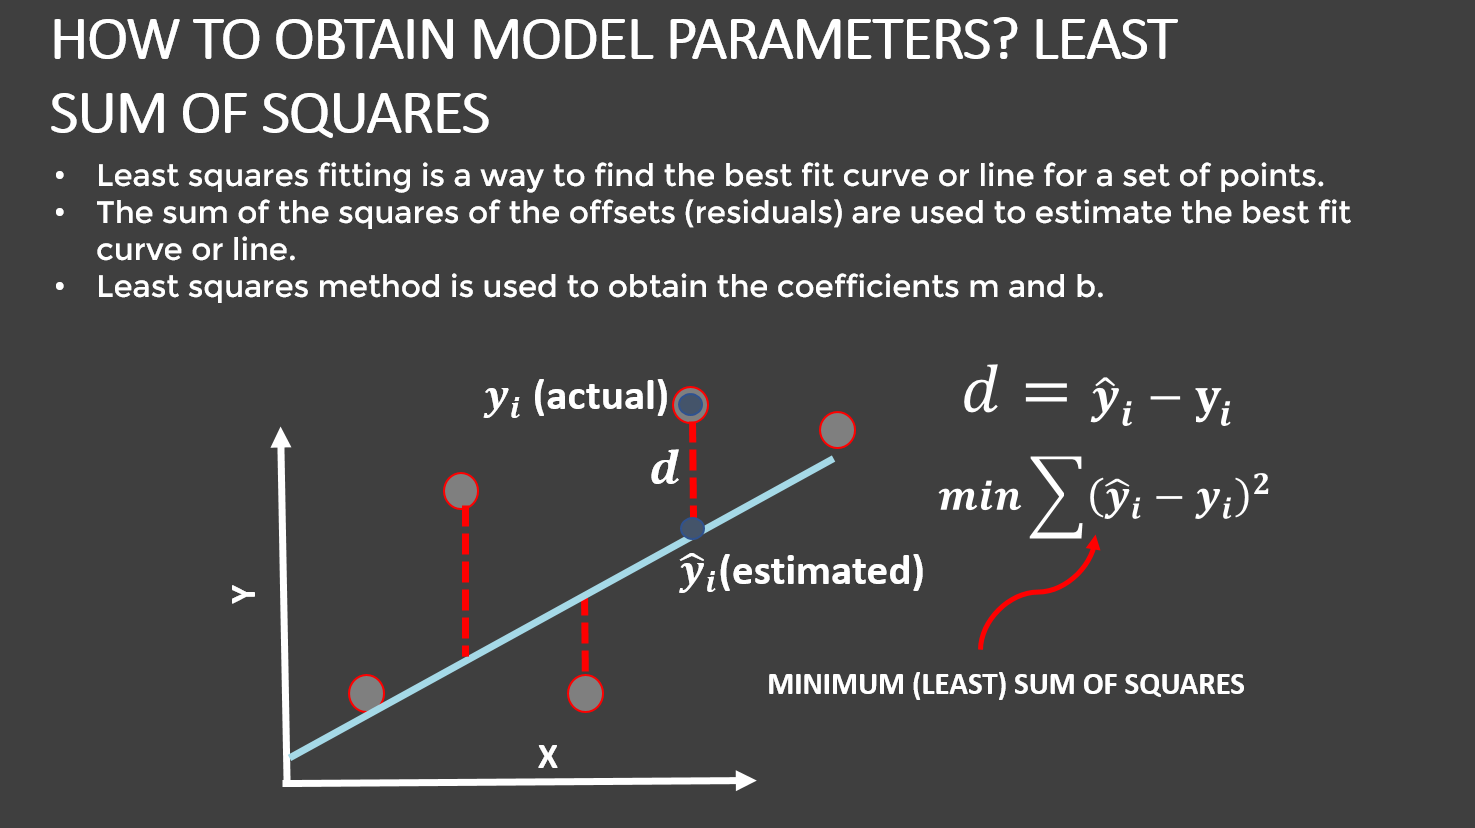<center>
</div>


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

LinearRegression_model = LinearRegression() # iniciamos una instancia del modelo de regresión lineal
LinearRegression_model.fit(X_train,y_train) # aplicamos el modelo de regresión lineal al set de entrenamiento, esto calculará los coeficientes (párametros) optimos que minimizan el error cuadrado.

LinearRegression()

### Evaluación del modelo de Regresión Lineal
* todo modelo de ML debe ser evaluado mediante ciertas métricas para determinar su performance.
* Para evaluar el modelo se deben probar los datos del conjunto de evaluación (test set)

#### Accuracy
* **Observación**: en regresión lineal, el metodo .score() devuelve el coeficiente de determinación, conocido como R^2, mientras que en clasificación devuelve la precisión media de las predicciones (accuracy). Por convención aun así llamaremos accuracy a la métrica de evaluación de regresión.

In [32]:
accuracy_LinearRegression = LinearRegression_model.score(X_test, y_test)
print(f"Accuracy Modelo de Regresión Lineal: {accuracy_LinearRegression}")

Accuracy Modelo de Regresión Lineal: -0.06394794091115541


* El accuracy del modelo de Regresión Lineal no es muy bueno, podemos indagar el por qué mediante el **Análisis de Residuos**.

#### Análisis de Residuos

[[ 0.54095005]
 [ 0.54989897]
 [ 0.58596566]
 ...
 [-0.43140356]
 [-0.41891483]
 [-0.4532425 ]]


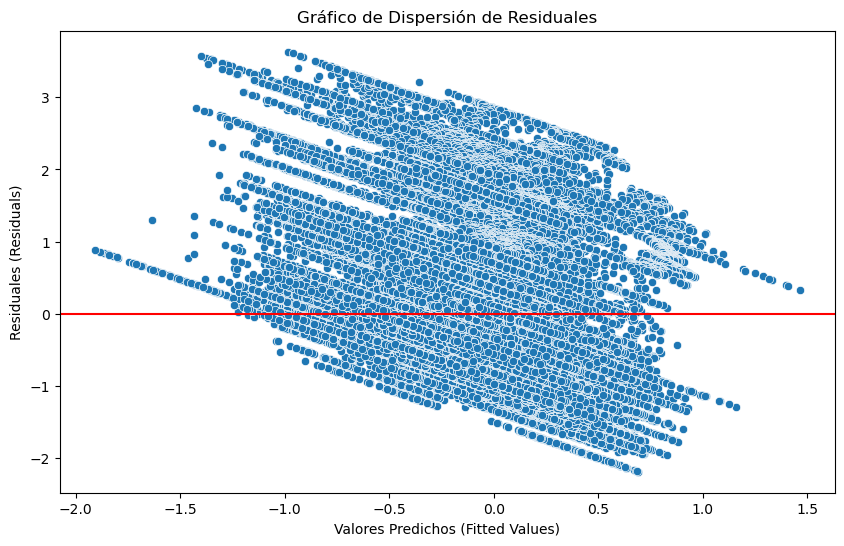

In [33]:
# Calculamos las predicciones del modelo:
y_pred = LinearRegression_model.predict(X_test)
print(y_pred)

# Convertimos las predicciones a un array 1D.
y_pred_1d = y_pred.flatten() if y_pred.ndim > 1 else y_pred
y_test_1d = y_test.flatten() if y_test.ndim > 1 else y_test

# Calculamos los residuales (error estimado) usando los arrays 1D.
residuales = y_test_1d - y_pred_1d

plt.figure(figsize=(10, 6))
# Visualizamos los residuales vs valores predecidos en un gráfico de dispersión
sns.scatterplot(x=y_pred_1d, y=residuales)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Valores Predichos (Fitted Values)')
plt.ylabel('Residuales (Residuals)')
plt.title('Gráfico de Dispersión de Residuales')
plt.show()

**¿Qué observamos?**
* Violación del supuesto de linealidad: el gráfico muestra una tendencia descendente, indicando un comportamient ono lineal ya que en una regresión lineal ideal el gráfico debería verse como una nube de puntos aleatoria y sin forma alrededor de la linea roja (residuo = 0)
* Estrías (Striations): fenómeno común en datos industriales y de sensores, representan diferentes estados de la planta que el modelo lineal está intentando representar.
* ¿Heterocedasticidad?: gráficamente se observa que la varianza de los residuales no es constante a traves de los valores predichos, mostrandose una forma de cono que es típica de este comportamiento.

**Conclusión**: claramente una regresión lineal no es lo suficientemente robusto para manejar la complejidad del dataset. Debido a esto, abordaremos el problema mediante otros algoritmos de ML más robustos: *Decision Trees* y *Random Forest*.

#### Análisis estadistico detallado (si se busca profundizar en las razones de este comportamiento)

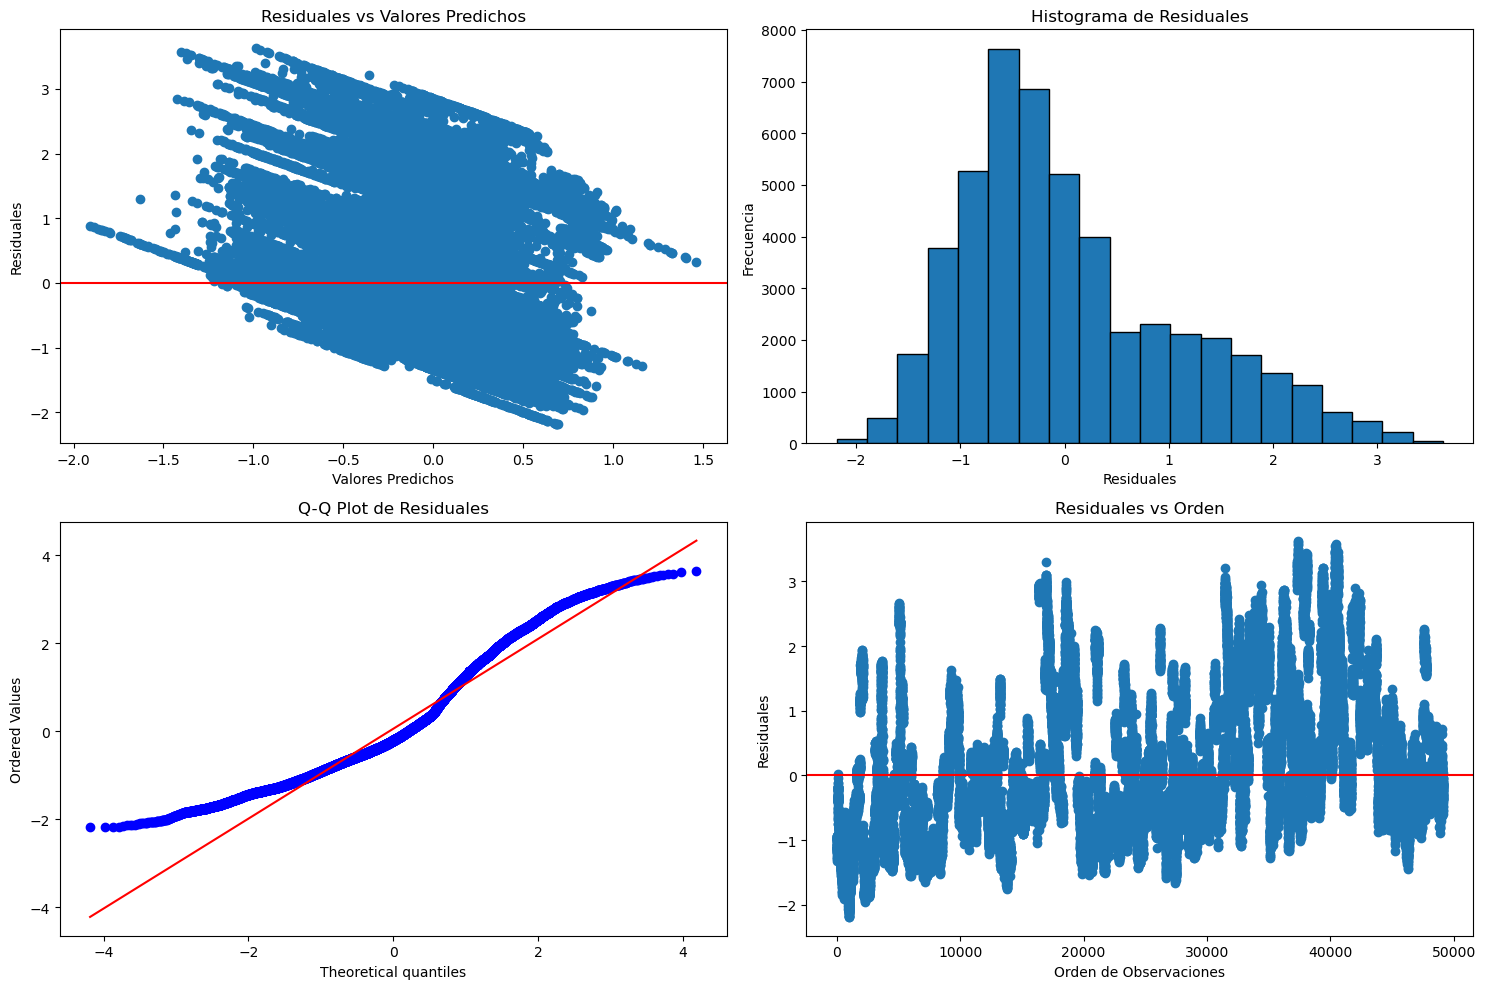

Estadísticas de los residuales:
Media: 0.0531
Desviación estándar: 1.0532
Mínimo: -2.1861
Máximo: 3.6305

Test de Shapiro-Wilk para normalidad:
Estadístico: 0.9404, p-valor: 0.0000
Los residuales no parecen ser normales (α = 0.05)


C:\Users\mauri\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 49140.
  res = hypotest_fun_out(*samples, **kwds)



Test de Breusch-Pagan para homocedasticidad:
Estadístico: 6623.8622, p-valor: 0.0000
Los residuales no parecen tener varianza constante (α = 0.05)


In [34]:
import scipy.stats as stats

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico de residuales vs valores ajustados
axes[0, 0].scatter(y_pred, residuales)
axes[0, 0].axhline(y=0, color='r', linestyle='-')
axes[0, 0].set_xlabel('Valores Predichos')
axes[0, 0].set_ylabel('Residuales')
axes[0, 0].set_title('Residuales vs Valores Predichos')

# Histograma de residuales
axes[0, 1].hist(residuales, bins=20, edgecolor='black')
axes[0, 1].set_xlabel('Residuales')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Histograma de Residuales')

# QQ plot para verificar normalidad
stats.probplot(residuales, plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot de Residuales')

# Residuales vs orden (si tienes un índice temporal)
axes[1, 1].scatter(range(len(residuales)), residuales)
axes[1, 1].axhline(y=0, color='r', linestyle='-')
axes[1, 1].set_xlabel('Orden de Observaciones')
axes[1, 1].set_ylabel('Residuales')
axes[1, 1].set_title('Residuales vs Orden')

plt.tight_layout()
plt.show()

# 4. Estadísticas descriptivas de los residuales
print("Estadísticas de los residuales:")
print(f"Media: {np.mean(residuales):.4f}")
print(f"Desviación estándar: {np.std(residuales):.4f}")
print(f"Mínimo: {np.min(residuales):.4f}")
print(f"Máximo: {np.max(residuales):.4f}")

# 5. Test de normalidad (Shapiro-Wilk)
from scipy.stats import shapiro
stat, p_value = shapiro(residuales)
print(f"\nTest de Shapiro-Wilk para normalidad:")
print(f"Estadístico: {stat:.4f}, p-valor: {p_value:.4f}")
print(f"Los residuales {'parecen ser normales' if p_value > 0.05 else 'no parecen ser normales'} (α = 0.05)")

# 6. Test de homocedasticidad (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

# Add a constant to X_test for the Breusch-Pagan test
X_test_with_const = sm.add_constant(X_test)  # Add a column of 1s to X_test

# Now run the test with the constant included
bp_test = het_breuschpagan(residuales, X_test_with_const)
print(f"\nTest de Breusch-Pagan para homocedasticidad:")
print(f"Estadístico: {bp_test[0]:.4f}, p-valor: {bp_test[1]:.4f}")
print(f"Los residuales {'parecen tener varianza constante' if bp_test[1] > 0.05 else 'no parecen tener varianza constante'} (α = 0.05)")

## Entrenamiento de otros modelos de ML

### Modelo de Decision Tree
* Los modelos de Decision Tree (Árbol de Decisión) construyen un modelo de regresión o clasificación en forma similar a las ramificaciones de un árbol.
* Un Decision Tree es un algoritmo no parametrico, lo que quiere ignora los supuestos estadísticos que vimos en el modelo anterior.
* El algoritmo descompone el dataset en pequeños subsets mientras que al mismo tiempo un arbol de decisión se empieza a desarrollar.
* * Es capaz de manejar la no-lineralidad del dataset.
* El resultado final es un árbol con nodos de decisión y nodos hoja.

In [35]:
from sklearn.tree import DecisionTreeRegressor

DecisionTree_model = DecisionTreeRegressor() # inicializamos una instancia del modelo
DecisionTree_model.fit(X_train,y_train) # entrenamos el modelo con el training set.


DecisionTreeRegressor()

### Evaluación del modelo de Decision Tree

In [36]:
accuracy_DecisionTree = DecisionTree_model.score(X_test,y_test)
print(f'Accuracy Modelo Decision Tree: {accuracy_DecisionTree}') 

Accuracy Modelo Decision Tree: -1.666750171692832


**Observaciones:**
* El accuracy del modelo de Decision Tree mejoro significativamente su performance vs el modelo de regresión lineal, sin embargo esto es engañoso.
* el problema de usar un solo Decision Tree para predecir un valor continuo (regresión) es que son modelos extremadamente "codiciosos" y propensos a memorizar los datos (**Overfitting**), por lo cuál **su accuracy tenderá a ser casi perfecto, siendo que no es la realidad**, además poseen una alta varianza, esto significa que no tendrá un buen desempeño al entregarle información nueva.
* Debido a esto, utilizar un Decision Tree sirve más como una herramienta exploratoria si no se ponen límites al crecimiento del árbol.
* Por lo general utilizar un Decision Tree simple no es suficiente para un proceso tan complejo como la flotación en una planta metalúrgica, por lo cuál utilizaremos técnicas más robustas (**modelos Ensemble**).

## Modelo Random Forest

* El Random Forest es una técnica de ML del tipo **modelo Ensemble**.
* Los modelos Ensemble (o de conjunto) se basan en **combinar múltiples modelos individuales para crear un predictor más robusto y preciso**, superando el rendimiento de cualquier modelo por si solo.
* Un modelo Random Forest consiste en una combinación de modelos Decision Tree, donde la predicción de cada arbol se promedia para obtener la predicción del modelo Random Forest.

In [37]:
from sklearn.ensemble import RandomForestRegressor
RandomForest_model = RandomForestRegressor(n_estimators =10, max_depth=10)
RandomForest_model.fit(X_train, y_train.ravel())

RandomForestRegressor(max_depth=10, n_estimators=10)

* El número de estimadores corresponde al número de árboles que se entrenarán en paralelo con el training set.

### Accuracy

In [38]:
accuracy_RandomForest = RandomForest_model.score(X_test,y_test)
print(f'Accuracy modelo Random Forest: {accuracy_RandomForest}')

Accuracy modelo Random Forest: -0.3690589423085675


## Modelo de Red Neuronal Artificial para regresión

In [39]:
#!pip install tensorflow

In [40]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.optimizers import Adam

In [41]:
#Adam optimization is a stochastic gradient descent method that is based on adaptive estimation of first-order and second-order moments.
optimizer = Adam(learning_rate=0.001, beta_1 = 0.9, beta_2 = 0.999, epsilon = 1e-07, amsgrad = False)
ANN_model = keras.Sequential()
ANN_model.add(Dense(250, input_dim = X_train.shape[1], kernel_initializer='normal',activation='relu'))
ANN_model.add(Dense(500,activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1000, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(500, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(250, activation = 'relu'))
ANN_model.add(Dropout(0.1))
ANN_model.add(Dense(1, activation = 'linear')) # activación lineal ya que el problema es de regresión
ANN_model.compile(loss = 'mse', optimizer = 'adam')
ANN_model.summary()





C:\Users\mauri\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 250)            │         5,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       125,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,001 (8.62 MB)

 Trainable params: 2,259,001 (8.62 MB)

 Non-trainable params: 0 (0.00 B)

* En la celda de arriba compilamos una red neuronal artificial, por lo que ahora su arquitectura está creada, solo queda entrenarla con nuestros datos.

#### Entrenamiento de la ANN

In [46]:
# Definimos Early Stopping:
# monitor: qué métrica vigilar
# patience: cuántas épocas esperar si el val_loss sube antes de detener todo (ej. esperar 3 épocas por si es solo un pico temporal)
# restore_best_weights: Al detenerse, regresa el modelo a la época  mejor.
from tensorflow.keras.callbacks import EarlyStopping

parada_temprana = EarlyStopping(
    monitor='val_loss', 
    patience=6, 
    restore_best_weights=True 
)
history = ANN_model.fit(X_train, 
                        y_train,
                        epochs =20,
                        validation_split=0.15,
                        callbacks=[parada_temprana],
                        verbose=1,
                        )

Epoch 1/20
5222/5222 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.4448 - val_loss: 1.2490
Epoch 2/20
5222/5222 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.3811 - val_loss: 1.4171
Epoch 3/20
5222/5222 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.3424 - val_loss: 1.3811
Epoch 4/20
5222/5222 ━━━━━━━━━━━━━━━━━━━━ 62s 12ms/step - loss: 0.3153 - val_loss: 1.2529
Epoch 5/20
5222/5222 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 0.2956 - val_loss: 1.2703
Epoch 6/20
5222/5222 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 0.2799 - val_loss: 1.4284
Epoch 7/20
5222/5222 ━━━━━━━━━━━━━━━━━━━━ 63s 12ms/step - loss: 0.2669 - val_loss: 1.3079


#### Evaluación de la ANN

In [47]:
from sklearn.metrics import r2_score

y_pred_scaled = ANN_model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_orig = scaler_y.inverse_transform(y_test)

r2_ANN = r2_score(y_test_orig, y_pred)
mse_ANN = mean_squared_error(y_test_orig, y_pred)
rmse_ANN = np.sqrt(mse_ANN)

print(f"R²:   {r2_ANN:.4f}")
print(f"RMSE: {rmse_ANN:.4f} % Silica")

1536/1536 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
R²:   -0.2735
RMSE: 1.2927 % Silica


In [48]:
history.history.keys()

dict_keys(['loss', 'val_loss'])

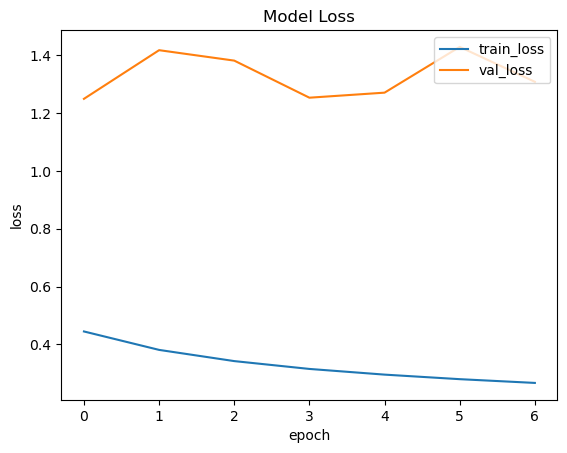

In [49]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss','val_loss'], loc = 'upper right')
plt.show()

* Podríamos mejorar la performance del modelo si extendemos las épocas de entrenamiento (probar con epoch =10)
* Entrenamiento óptimo en epoch 7.
